# Neural Network Curve Fit and Future Simulation

## Goal

Choose a few parameters, train a neural network on noisy observations, and then look far into the future to decide whether the predicted curve still matches the data.

The network sees only the gray observed points. The orange future points are simulated **after** the training range and are not used to train the model. The dashed sine curve is shown only as a reference.

The main question is visual:

> Does the blue neural-network curve follow the data now, and does it continue to follow the future data?


## Setup: choose the parameters

Change the values in the next cell, then use **Kernel → Restart Kernel and Run All Cells**.

| Parameter | What it changes | Good values to try |
|---|---|---|
| `OBSERVED_CYCLES` | How much history the model sees | 1, 2, 4, 6 |
| `FUTURE_CYCLES` | How far ahead the simulation runs | 5, 10, 20 |
| `OBSERVED_POINTS` | Number of training observations | 60, 120, 240, 500 |
| `NOISE_STD` | How scattered the data are | 0.00, 0.10, 0.25 |
| `HIDDEN_LAYERS` | Number of hidden layers | 1, 2, 3 |
| `NEURONS_PER_LAYER` | Size of each hidden layer | 8, 32, 64, 128 |
| `ACTIVATION` | Shape used inside the network | `"tanh"`, `"relu"`, `"logistic"` |
| `TRAINING_ITERATIONS` | How long the model trains | 200, 500, 1000, 2000 |
| `LEARNING_RATE` | Size of each training adjustment | 0.0005, 0.001, 0.003, 0.01 |

This notebook uses NumPy, Matplotlib, and scikit-learn. If needed, install them with `pip install numpy matplotlib scikit-learn`.


In [7]:
# ============================================================
# STUDENT SETTINGS: change values here, then run all cells
# ============================================================

RANDOM_SEED = 42

# Data and simulation
OBSERVED_CYCLES = 2          # Amount of history shown to the model
FUTURE_CYCLES = 10           # Extra cycles simulated after the history
OBSERVED_POINTS = 240
FUTURE_POINTS_PER_CYCLE = 30
NOISE_STD = 0.10

# Neural-network shape
HIDDEN_LAYERS = 2
NEURONS_PER_LAYER = 64
ACTIVATION = "tanh"          # "tanh", "relu", or "logistic"

# Training
TRAINING_ITERATIONS = 1000
LEARNING_RATE = 0.003


## Step 1: create observed and future data

The observed data cover the first few cycles. The future simulation begins immediately after the last observed point and continues for the number of cycles selected above.


In [8]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*")

if OBSERVED_CYCLES <= 0 or FUTURE_CYCLES <= 0:
    raise ValueError("OBSERVED_CYCLES and FUTURE_CYCLES must be positive.")
if OBSERVED_POINTS < 10 or FUTURE_POINTS_PER_CYCLE < 2:
    raise ValueError("Use at least 10 observed points and 2 future points per cycle.")
if NOISE_STD < 0:
    raise ValueError("NOISE_STD cannot be negative.")

rng = np.random.default_rng(RANDOM_SEED)
cycle_length = 2 * np.pi
observed_end = OBSERVED_CYCLES * cycle_length
future_end = (OBSERVED_CYCLES + FUTURE_CYCLES) * cycle_length

x_observed = np.linspace(0, observed_end, OBSERVED_POINTS).reshape(-1, 1)
y_observed = np.sin(x_observed[:, 0]) + rng.normal(0, NOISE_STD, OBSERVED_POINTS)

future_point_count = FUTURE_CYCLES * FUTURE_POINTS_PER_CYCLE
future_step = cycle_length / FUTURE_POINTS_PER_CYCLE
x_future_data = np.linspace(
    observed_end + future_step,
    future_end,
    future_point_count,
).reshape(-1, 1)
y_future_data = np.sin(x_future_data[:, 0]) + rng.normal(
    0,
    NOISE_STD,
    future_point_count,
)

print(f"Observed range: 0 to {OBSERVED_CYCLES} cycles ({OBSERVED_POINTS} points)")
print(f"Future range: {OBSERVED_CYCLES} to {OBSERVED_CYCLES + FUTURE_CYCLES} cycles "
      f"({future_point_count} new points)")


Observed range: 0 to 2 cycles (240 points)
Future range: 2 to 12 cycles (300 new points)


## Step 2: train the neural network

The model is trained only on `x_observed` and `y_observed`. The input is rescaled so the model trains more reliably. The training details are kept short so the focus stays on the curve and the future simulation.


In [9]:
if HIDDEN_LAYERS < 1 or NEURONS_PER_LAYER < 1:
    raise ValueError("Use at least one hidden layer and one neuron per layer.")
if ACTIVATION not in {"tanh", "relu", "logistic"}:
    raise ValueError('ACTIVATION must be "tanh", "relu", or "logistic".')
if TRAINING_ITERATIONS < 1 or LEARNING_RATE <= 0:
    raise ValueError("TRAINING_ITERATIONS and LEARNING_RATE must be positive.")

x_center = x_observed.mean()
x_scale = x_observed.std()

def scale_x(values):
    return (values - x_center) / x_scale

layer_shape = (NEURONS_PER_LAYER,) * HIDDEN_LAYERS
network = MLPRegressor(
    hidden_layer_sizes=layer_shape,
    activation=ACTIVATION,
    solver="adam",
    learning_rate_init=LEARNING_RATE,
    max_iter=TRAINING_ITERATIONS,
    random_state=RANDOM_SEED,
    tol=1e-8,
    n_iter_no_change=TRAINING_ITERATIONS + 1,
)
network.fit(scale_x(x_observed), y_observed)

print(f"Network shape: {HIDDEN_LAYERS} hidden layer(s), "
      f"{NEURONS_PER_LAYER} neurons each, {ACTIVATION} activation")
print(f"Training finished after {network.n_iter_} iterations")


Network shape: 2 hidden layer(s), 64 neurons each, tanh activation
Training finished after 1000 iterations


In [10]:
# ============================================================
# Step 2b: compute the final training loss
# ============================================================

final_predictions = network.predict(scale_x(x_observed))
final_loss = np.mean((final_predictions - y_observed) ** 2)

print(f"Final training loss (MSE on observed data): {final_loss:.6f}")
print(f"Sklearn training loss_: {network.loss_:.6f}")


Final training loss (MSE on observed data): 0.008409
Sklearn training loss_: 0.004373


## Step 3: compare the curve with data far into the future

The left panel zooms in on the data used for training. The right panel extends the same prediction through the full future simulation.


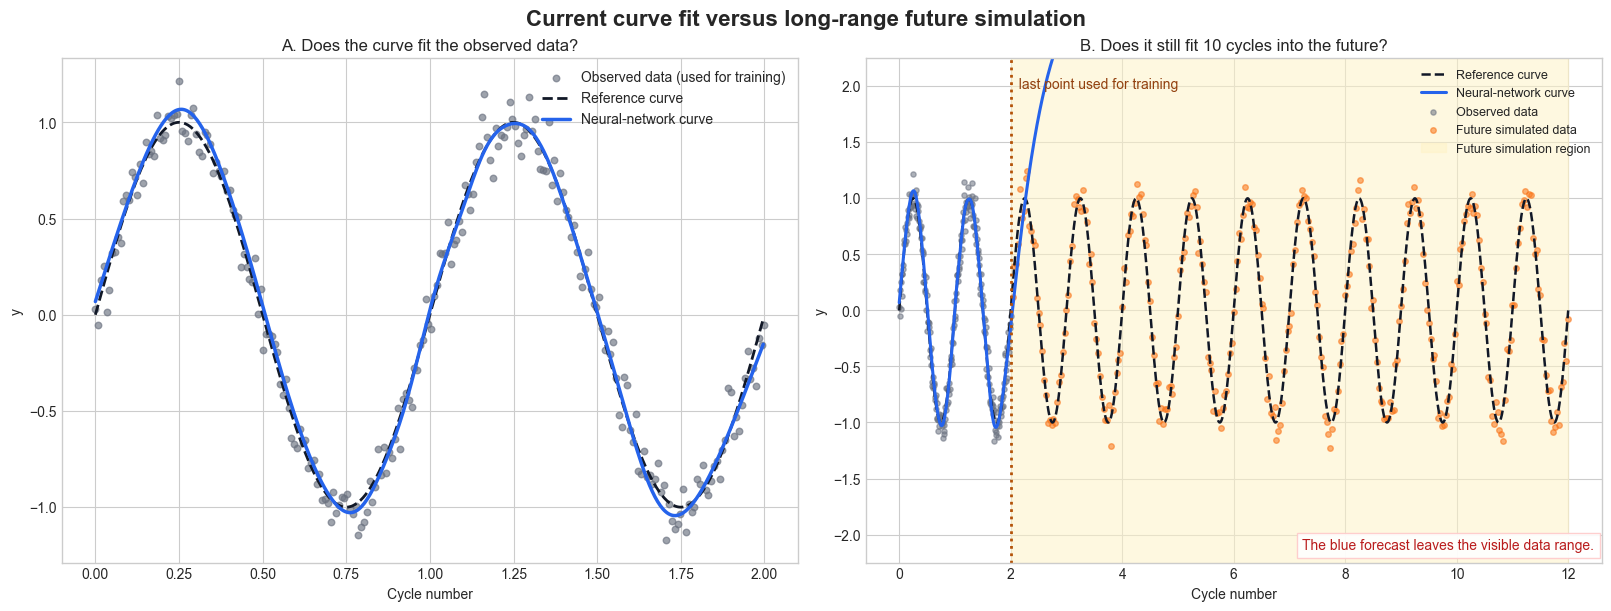

In [11]:
curve_point_count = max(2000, (OBSERVED_CYCLES + FUTURE_CYCLES) * 250)
x_curve = np.linspace(0, future_end, curve_point_count).reshape(-1, 1)
y_network_curve = network.predict(scale_x(x_curve))
y_reference_curve = np.sin(x_curve[:, 0])
curve_cycles = x_curve[:, 0] / cycle_length
observed_mask = x_curve[:, 0] <= observed_end

plt.style.use("seaborn-v0_8-whitegrid")
fig, (fit_ax, future_ax) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    constrained_layout=True,
)

# Close-up: how well does the curve follow the observed data?
fit_ax.scatter(
    x_observed[:, 0] / cycle_length,
    y_observed,
    s=22,
    color="#6b7280",
    alpha=0.65,
    label="Observed data (used for training)",
)
fit_ax.plot(
    curve_cycles[observed_mask],
    y_reference_curve[observed_mask],
    color="#111827",
    linestyle="--",
    linewidth=2,
    label="Reference curve",
)
fit_ax.plot(
    curve_cycles[observed_mask],
    y_network_curve[observed_mask],
    color="#2563eb",
    linewidth=2.5,
    label="Neural-network curve",
)
fit_ax.set_title("A. Does the curve fit the observed data?")
fit_ax.set_xlabel("Cycle number")
fit_ax.set_ylabel("y")
fit_ax.legend(loc="upper right")

# Long view: does the prediction continue to match new simulated data?
future_ax.axvspan(
    OBSERVED_CYCLES,
    OBSERVED_CYCLES + FUTURE_CYCLES,
    color="#fef3c7",
    alpha=0.55,
    label="Future simulation region",
)
future_ax.plot(
    curve_cycles,
    y_reference_curve,
    color="#111827",
    linestyle="--",
    linewidth=1.8,
    label="Reference curve",
)
future_ax.plot(
    curve_cycles,
    y_network_curve,
    color="#2563eb",
    linewidth=2.2,
    label="Neural-network curve",
)
future_ax.scatter(
    x_observed[:, 0] / cycle_length,
    y_observed,
    s=14,
    color="#6b7280",
    alpha=0.55,
    label="Observed data",
)
future_ax.scatter(
    x_future_data[:, 0] / cycle_length,
    y_future_data,
    s=16,
    color="#f97316",
    alpha=0.55,
    label="Future simulated data",
)
future_ax.axvline(
    OBSERVED_CYCLES,
    color="#b45309",
    linestyle=":",
    linewidth=2,
)
future_ax.text(
    OBSERVED_CYCLES,
    2.08,
    "  last point used for training",
    color="#92400e",
    va="top",
)
future_ax.set_title(f"B. Does it still fit {FUTURE_CYCLES} cycles into the future?")
future_ax.set_xlabel("Cycle number")
future_ax.set_ylabel("y")
future_ax.set_ylim(-2.25, 2.25)

future_predictions = y_network_curve[~observed_mask]
if np.max(np.abs(future_predictions)) > 2.25:
    future_ax.text(
        0.99,
        0.02,
        "The blue forecast leaves the visible data range.",
        transform=future_ax.transAxes,
        ha="right",
        va="bottom",
        color="#b91c1c",
        bbox={"facecolor": "white", "edgecolor": "#fecaca", "alpha": 0.9},
    )

handles, labels = future_ax.get_legend_handles_labels()
legend_order = [1, 2, 3, 4, 0]
future_ax.legend(
    [handles[index] for index in legend_order],
    [labels[index] for index in legend_order],
    loc="upper right",
    fontsize=9,
)

fig.suptitle(
    "Current curve fit versus long-range future simulation",
    fontsize=16,
    fontweight="bold",
)
plt.show()


In [12]:
# ============================================================
# Step 3b: compute the validation loss
# ============================================================

validation_predictions = network.predict(scale_x(x_future_data))
validation_loss = np.mean((validation_predictions - y_future_data) ** 2)

print(f"Validation loss (MSE on future simulated data): {validation_loss:.6f}")


Validation loss (MSE on future simulated data): 10.268629


## Checks: does the curve fit?

Use the graph rather than a training score:

1. **Observed fit:** In panel A, does the blue line pass through the middle of the gray cloud without chasing every noisy point?
2. **Near future:** Just after the vertical divider in panel B, is the blue line still close to the orange points?
3. **Far future:** Near the right edge, does the blue line still follow the orange pattern, or does it flatten, drift, or leave the visible range?

A model can fit the observed data well and still make a poor long-range forecast. That contrast is the main lesson of this simulation.


## Next steps: run your own simulations

Change one setting at a time and rerun the notebook.

| Experiment | Change | Question to answer from the graph |
|---|---|---|
| More history | `OBSERVED_CYCLES = 4` or `6` | Does seeing more cycles improve the future curve? |
| Much farther ahead | `FUTURE_CYCLES = 20` | How quickly does the forecast drift away? |
| Less data | `OBSERVED_POINTS = 60` | Can the network still find the pattern? |
| Noisier data | `NOISE_STD = 0.25` | Does the curve follow the signal or the noise? |
| Smaller network | `HIDDEN_LAYERS = 1`, `NEURONS_PER_LAYER = 8` | Is the curve flexible enough? |
| Wider network | `NEURONS_PER_LAYER = 128` | Does a larger network improve the fit? |
| Different shape | Change `ACTIVATION` | Which setting follows the current and future data best? |

Record each run in a simple table:

| Run | Parameters changed | Fits observed data? | Fits near future? | Fits far future? | What happened? |
|---:|---|---|---|---|---|
| 1 |  |  |  |  |  |
| 2 |  |  |  |  |  |
| 3 |  |  |  |  |  |
